# Minggu 1: Data Preprocessing, EDA, RFM, Cohort Baseline
Eksekusi plan dari DETAILEDPLAN.md untuk minggu 1.


## Hari 1: Setup dan Audit Dataset


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

# Set style
sns.set_theme(style="whitegrid")


In [2]:
# Load dataset UCI Online Retail II
# Because the dataset is large, we might need to specify the encoding
df = pd.read_csv('online_retail_II.csv')

# Validasi kolom wajib
print("Kolom dataset:", df.columns.tolist())


Kolom dataset: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']


In [3]:
# Data Audit Awal
print("Jumlah row:", len(df))
print("Jumlah customer unik:", df['Customer ID'].nunique())
print("Jumlah invoice unik:", df['Invoice'].nunique())
print("\nMissing value per kolom:\n", df.isnull().sum())
print("\nDuplikat:", df.duplicated().sum())

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print("\nRange tanggal transaksi:", df['InvoiceDate'].min(), "sampai", df['InvoiceDate'].max())

# Transaksi cancel
cancelled = df[df['Invoice'].astype(str).str.startswith('C')]
print("\nJumlah transaksi cancel (prefix C):", len(cancelled))


Jumlah row: 1067371
Jumlah customer unik: 5942
Jumlah invoice unik: 53628

Missing value per kolom:
 Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

Duplikat: 34335

Range tanggal transaksi: 2009-12-01 07:45:00 sampai 2011-12-09 12:50:00

Jumlah transaksi cancel (prefix C): 19494


## Hari 2: Cleaning dan Data Validation


In [4]:
# Terapkan preprocessing
df_clean = df.copy()

# Drop missing Customer ID
df_clean = df_clean.dropna(subset=['Customer ID'])

# Buang invoice cancel
df_clean = df_clean[~df_clean['Invoice'].astype(str).str.startswith('C')]

# Filter Quantity > 0 dan Price > 0
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['Price'] > 0)]

# Buat kolom TotalPrice
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['Price']

print("Before cleaning row count:", len(df))
print("After cleaning row count:", len(df_clean))


Before cleaning row count: 1067371
After cleaning row count: 805549


In [5]:
# Simpan dataframe bersih
df_clean.to_csv('clean_transactions.csv', index=False)
print("Saved clean_transactions.csv")


Saved clean_transactions.csv


## Hari 3: EDA Customer dan Sales


In [6]:
# Top customer by total purchase
top_customers = df_clean.groupby('Customer ID')['TotalPrice'].sum().sort_values(ascending=False).head(10)
print("Top 10 Customers by Revenue:\n", top_customers)


Top 10 Customers by Revenue:
 Customer ID
18102.0    608821.65
14646.0    528602.52
14156.0    313946.37
14911.0    295972.63
17450.0    246973.09
13694.0    196482.81
17511.0    175603.55
16446.0    168472.50
16684.0    147142.77
12415.0    144458.37
Name: TotalPrice, dtype: float64


/tmp/ipykernel_21852/2607266966.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_revenue.values, y=country_revenue.index, palette='viridis')


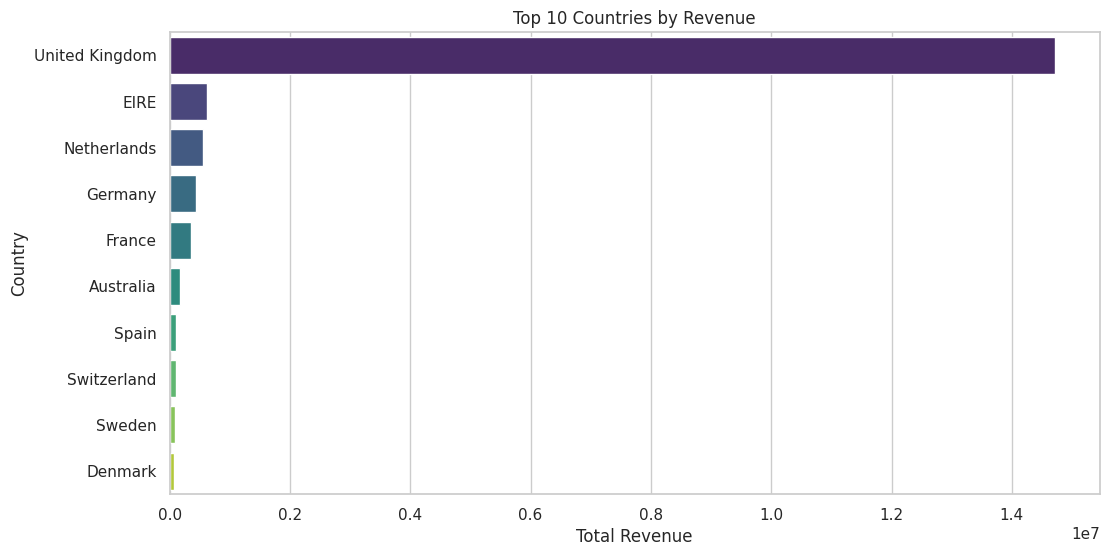

In [7]:
# Country by revenue
plt.figure(figsize=(12,6))
country_revenue = df_clean.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=country_revenue.values, y=country_revenue.index, palette='viridis')
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Country')
plt.show()


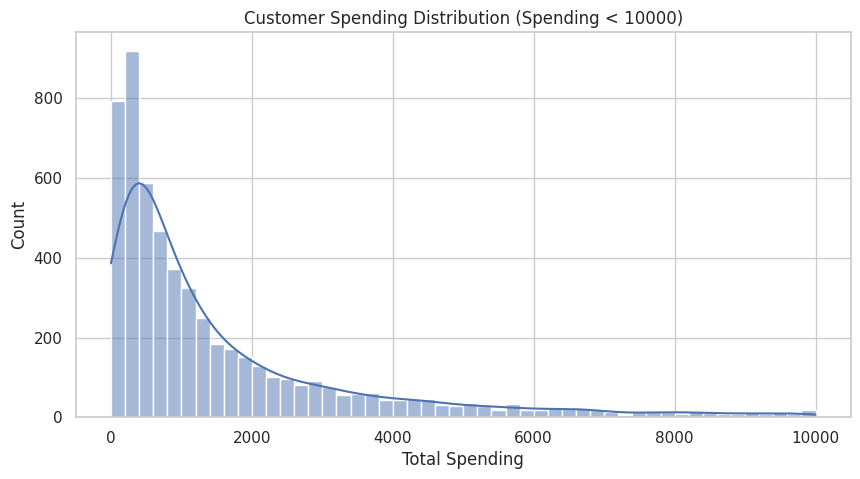

In [8]:
# Customer spending distribution (Outliers removed for visualization)
plt.figure(figsize=(10,5))
spending = df_clean.groupby('Customer ID')['TotalPrice'].sum()
sns.histplot(spending[spending < 10000], bins=50, kde=True)
plt.title('Customer Spending Distribution (Spending < 10000)')
plt.xlabel('Total Spending')
plt.show()


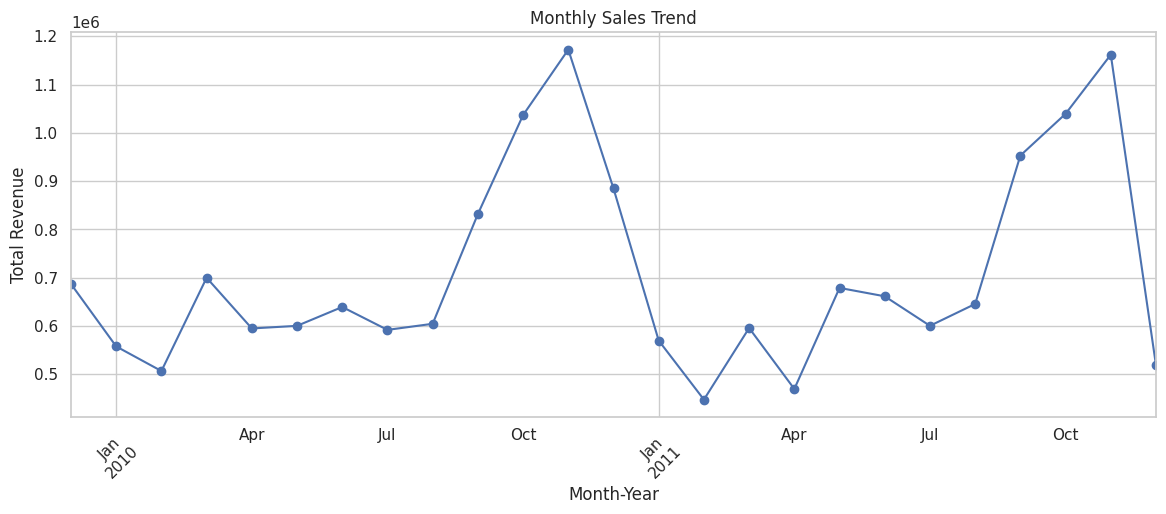

In [9]:
# Monthly sales trend
df_clean['MonthYear'] = df_clean['InvoiceDate'].dt.to_period('M')
monthly_sales = df_clean.groupby('MonthYear')['TotalPrice'].sum()

plt.figure(figsize=(14,5))
monthly_sales.plot(marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month-Year')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()


## Hari 4: RFM Feature Engineering


In [10]:
# Reference date
reference_date = df_clean['InvoiceDate'].max() + dt.timedelta(days=1)
print("Reference Date:", reference_date)

# Hitung RFM
rfm = df_clean.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'Invoice': 'nunique',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()


Reference Date: 2011-12-10 12:50:00


,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,12,77556.46
12347.0,2,8,5633.32
12348.0,75,5,2019.40
12349.0,19,4,4428.69
12350.0,310,1,334.40


In [11]:
# Score RFM
# Recency: lower is better (5 is best)
rfm['RecencyScore'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])

# Frequency: higher is better
# Use rank method for Frequency because many customers might have the same frequency (e.g., 1)
rfm['FrequencyScore'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])

# Monetary: higher is better
rfm['MonetaryScore'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])

rfm['RF_Score'] = rfm['RecencyScore'].astype(str) + rfm['FrequencyScore'].astype(str)
rfm.head()


,Recency,Frequency,Monetary,RecencyScore,FrequencyScore,MonetaryScore,RF_Score
Customer ID,,,,,,,
12346.0,326,12,77556.46,2,5,5,25
12347.0,2,8,5633.32,5,4,5,54
12348.0,75,5,2019.40,3,4,4,34
12349.0,19,4,4428.69,5,3,5,53
12350.0,310,1,334.40,2,1,2,21


In [12]:
# Mapping segment awal
seg_map = {
    r'[1-2][1-2]': 'Hibernating',
    r'[1-2][3-4]': 'At Risk',
    r'[1-2]5': 'Can\'t Loose',
    r'3[1-2]': 'About To Sleep',
    r'33': 'Need Attention',
    r'[3-4][4-5]': 'Loyal Customers',
    r'41': 'Promising',
    r'51': 'New Customers',
    r'[4-5][2-3]': 'Potential Loyalists',
    r'5[4-5]': 'Champions'
}

rfm['Segment'] = rfm['RF_Score'].replace(seg_map, regex=True)

print(rfm['Segment'].value_counts())


Segment
Hibernating            1523
Loyal Customers        1161
Champions               837
At Risk                 753
Potential Loyalists     714
About To Sleep          385
Need Attention          266
Promising               114
Can't Loose              71
New Customers            54
Name: count, dtype: int64


## Hari 5: Validasi RFM dan Outlier


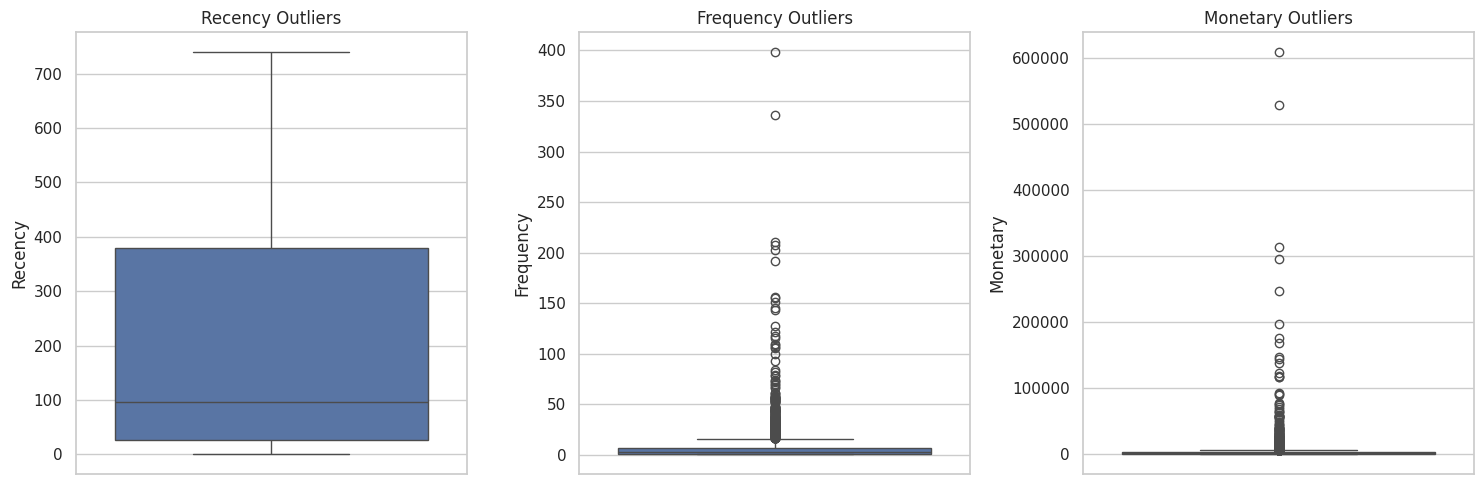

In [13]:
plt.figure(figsize=(15, 5))
plt.subplot(1,3,1)
sns.boxplot(y=rfm['Recency'])
plt.title('Recency Outliers')

plt.subplot(1,3,2)
sns.boxplot(y=rfm['Frequency'])
plt.title('Frequency Outliers')

plt.subplot(1,3,3)
sns.boxplot(y=rfm['Monetary'])
plt.title('Monetary Outliers')

plt.tight_layout()
plt.show()


In [14]:
# Validasi segment profil
rfm_profile = rfm.groupby('Segment').agg({
    'Recency': ['mean', 'count'],
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(2)
print("RFM Segment Profile:\n", rfm_profile)


RFM Segment Profile:
                     Recency       Frequency  Monetary
                       mean count      mean      mean
Segment                                              
About To Sleep       107.11   385      1.36    534.07
At Risk              372.67   753      3.90   1382.10
Can't Loose          331.23    71     15.93   8355.68
Champions              8.56   837     19.34  10901.13
Hibernating          459.28  1523      1.25    438.03
Loyal Customers       67.07  1161      9.84   4211.84
Need Attention       113.36   266      3.15   1283.66
New Customers         10.50    54      1.00    360.67
Potential Loyalists   25.76   714      2.59   1155.71
Promising             38.83   114      1.00    319.43


## Hari 6: Cohort Retention Baseline


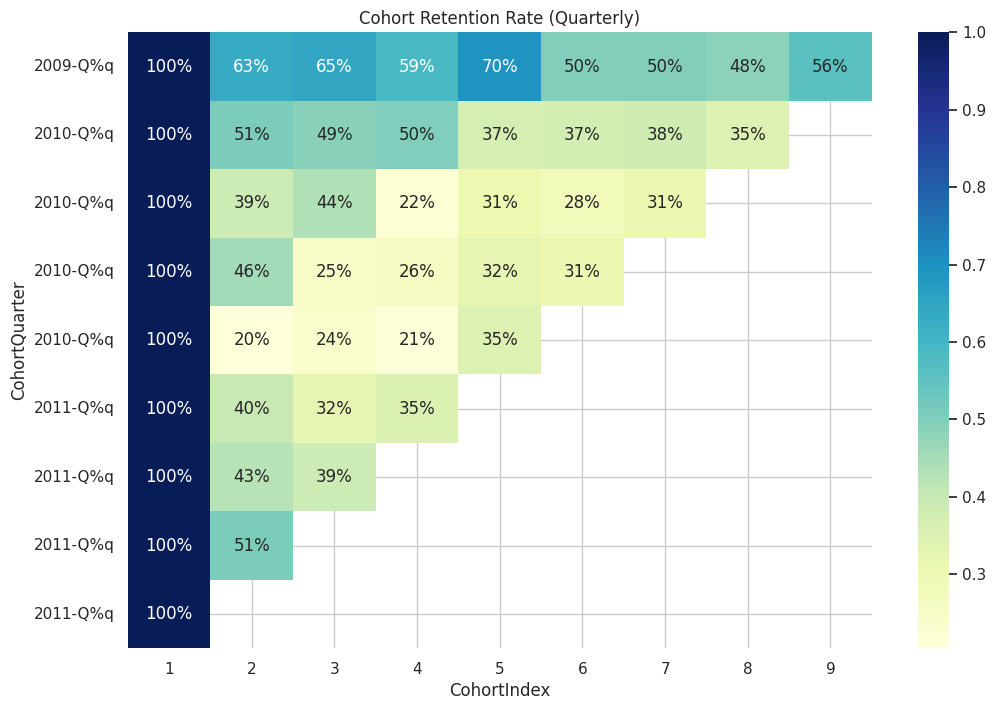

In [15]:
# Cohort berbasis Quarter
def get_quarter(x): return dt.datetime(x.year, (x.month-1)//3 * 3 + 1, 1)

df_clean['InvoiceQuarter'] = df_clean['InvoiceDate'].apply(get_quarter)
grouping = df_clean.groupby('Customer ID')['InvoiceQuarter']
df_clean['CohortQuarter'] = grouping.transform('min')

import numpy as np
def get_date_int(df, column):
    year = df[column].dt.year
    quarter = df[column].dt.quarter
    return year, quarter

invoice_year, invoice_quarter = get_date_int(df_clean, 'InvoiceQuarter')
cohort_year, cohort_quarter = get_date_int(df_clean, 'CohortQuarter')

years_diff = invoice_year - cohort_year
quarters_diff = invoice_quarter - cohort_quarter

df_clean['CohortIndex'] = years_diff * 4 + quarters_diff + 1

# Retention Matrix
grouping = df_clean.groupby(['CohortQuarter', 'CohortIndex'])
cohort_data = grouping['Customer ID'].apply(pd.Series.nunique).reset_index()
cohort_counts = cohort_data.pivot(index='CohortQuarter', columns='CohortIndex', values='Customer ID')

# Calculate retention rate
cohort_sizes = cohort_counts.iloc[:,0]
retention = cohort_counts.divide(cohort_sizes, axis=0)
retention.index = retention.index.strftime('%Y-Q%q')

plt.figure(figsize=(12, 8))
sns.heatmap(retention, annot=True, fmt='.0%', cmap='YlGnBu')
plt.title('Cohort Retention Rate (Quarterly)')
plt.show()


## Hari 7: Dokumentasi Minggu 1 dan Data Contract


In [16]:
# Tambahkan Country ke RFM
customer_country = df_clean.groupby('Customer ID')['Country'].first()
rfm = rfm.join(customer_country)

# Simpan RFM table
rfm.to_csv('rfm_customer_table.csv')
print("Saved rfm_customer_table.csv")

# Simpan Cohort Retention Matrix
retention.to_csv('cohort_retention_matrix.csv')
print("Saved cohort_retention_matrix.csv")

print("Minggu 1 Selesai!")


Saved rfm_customer_table.csv
Saved cohort_retention_matrix.csv
Minggu 1 Selesai!
